## Dataset Reference

This project uses the TACO dataset:

Proença, P. F., & Simões, P. (2020).
TACO: Trash Annotations in Context for Litter Detection.
arXiv preprint arXiv:2003.06975.
https://arxiv.org/abs/2003.06975

# Phase 1 — Data Preprocessing for MobileNetV2
### Waste Classification System — TACO Dataset

**Pipeline:**
1. Install dependencies
2. Download TACO dataset
3. Map categories → Recyclable / Non-Recyclable
4. Audit raw class distribution
5. Balance to exactly **1,000 images per class**
6. Preprocess — resize to 224×224, normalize
7. Stratified split — 70% train / 15% val / 15% test
8. Apply class weights for loss function
9. Save preprocessed splits

**Target:** 1,000 Recyclable + 1,000 Non-Recyclable = 2,000 total

**Split result:**
- Train : 1,400 (700 per class)
- Val   :   300 (150 per class)
- Test  :   300 (150 per class)

In [ ]:
!pip install pycocotools -q

In [ ]:
import os
import json
import random
import shutil
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from PIL import Image, ImageEnhance, ImageOps
from tqdm import tqdm
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

# ── Reproducibility ────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print('Imports successful.')

Device : cpu
Imports successful.


In [ ]:
# ── Image settings ─────────────────────────────────────────────
IMAGE_SIZE      = 224          # MobileNetV2 & ResNet-50 input size
TARGET_PER_CLASS = 1000        # balanced target per class

# ── Split ratios ───────────────────────────────────────────────
TRAIN_RATIO     = 0.70
VAL_RATIO       = 0.15
TEST_RATIO      = 0.15

# ── Output ─────────────────────────────────────────────────────
OUTPUT_PKL      = 'taco_preprocessed_balanced.pkl'
CLASS_NAMES     = ['Recyclable', 'Non-Recyclable']

# ── Recyclable category names (from TACO) ──────────────────────
RECYCLABLE_CATEGORIES = {
    'Aluminium foil', 'Bottle', 'Bottle cap', 'Broken glass',
    'Can', 'Carton', 'Cup', 'Glass bottle', 'Lid',
    'Metal bottle cap', 'Other plastic bottle', 'Paper',
    'Paper bag', 'Plastic bottle', 'Plastic bottle cap',
    'Plastic cup', 'Plastic lid', 'Pop tab', 'Tin can',
    'Tupperware', 'Wrapping paper', 'Cardboard'
}

print(f'Target per class : {TARGET_PER_CLASS}')
print(f'Total dataset    : {TARGET_PER_CLASS * 2}')
print(f'Train / Val / Test: {int(TARGET_PER_CLASS*2*TRAIN_RATIO)} / '
      f'{int(TARGET_PER_CLASS*2*VAL_RATIO)} / '
      f'{int(TARGET_PER_CLASS*2*TEST_RATIO)}')

Target per class : 1000
Total dataset    : 2000
Train / Val / Test: 1400 / 300 / 300


In [ ]:
if not os.path.exists('TACO'):
    !git clone https://github.com/pedropro/TACO.git

%cd TACO
!pip install -r requirements.txt -q
!python download.py

print('TACO download complete.')

Cloning into 'TACO'...
remote: Enumerating objects: 740, done.
remote: Counting objects: 100% (435/435), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 740 (delta 416), reused 380 (delta 380), pack-reused 305 (from 1)
Receiving objects: 100% (740/740), 97.48 MiB | 18.29 MiB/s, done.
Resolving deltas: 100% (499/499), done.
/content/TACO
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.5/12.5 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 24.3 MB/s eta 0:00:00
Note. If for any reason the connection is broken. Just call me again and I will start where I left.
Finished
TACO download complete.


In [ ]:
with open('data/annotations.json', 'r') as f:
    taco = json.load(f)

print(f'Total images      : {len(taco["images"])}')
print(f'Total annotations : {len(taco["annotations"])}')
print(f'Total categories  : {len(taco["categories"])}')

# Map category id → binary label
# 0 = Recyclable, 1 = Non-Recyclable
cat_id_to_class = {}
for cat in taco['categories']:
    name = cat['name']
    label = 0 if name in RECYCLABLE_CATEGORIES else 1
    cat_id_to_class[cat['id']] = label

recyclable_cats = [c['name'] for c in taco['categories']
                   if c['name'] in RECYCLABLE_CATEGORIES]
non_recyclable_cats = [c['name'] for c in taco['categories']
                       if c['name'] not in RECYCLABLE_CATEGORIES]

print(f'\nRecyclable categories    ({len(recyclable_cats)}):')
for n in sorted(recyclable_cats):
    print(f'  ✅ {n}')

print(f'\nNon-Recyclable categories ({len(non_recyclable_cats)}):')
for n in sorted(non_recyclable_cats):
    print(f'  ❌ {n}')

Total images      : 1500
Total annotations : 4784
Total categories  : 60

Recyclable categories    (11):
  ✅ Aluminium foil
  ✅ Broken glass
  ✅ Glass bottle
  ✅ Metal bottle cap
  ✅ Other plastic bottle
  ✅ Paper bag
  ✅ Plastic bottle cap
  ✅ Plastic lid
  ✅ Pop tab
  ✅ Tupperware
  ✅ Wrapping paper

Non-Recyclable categories (49):
  ❌ Aerosol
  ❌ Aluminium blister pack
  ❌ Battery
  ❌ Carded blister pack
  ❌ Cigarette
  ❌ Clear plastic bottle
  ❌ Corrugated carton
  ❌ Crisp packet
  ❌ Disposable food container
  ❌ Disposable plastic cup
  ❌ Drink can
  ❌ Drink carton
  ❌ Egg carton
  ❌ Foam cup
  ❌ Foam food container
  ❌ Food Can
  ❌ Food waste
  ❌ Garbage bag
  ❌ Glass cup
  ❌ Glass jar
  ❌ Magazine paper
  ❌ Meal carton
  ❌ Metal lid
  ❌ Normal paper
  ❌ Other carton
  ❌ Other plastic
  ❌ Other plastic container
  ❌ Other plastic cup
  ❌ Other plastic wrapper
  ❌ Paper cup
  ❌ Paper straw
  ❌ Pizza box
  ❌ Plastic film
  ❌ Plastic glooves
  ❌ Plastic straw
  ❌ Plastic utensils
  

In [ ]:
img_id_to_path = {
    img['id']: os.path.join('data', img['file_name'])
    for img in taco['images']
}

seen_images = set()
raw_recyclable     = []   # list of image paths
raw_non_recyclable = []   # list of image paths

for ann in taco['annotations']:
    img_id = ann['image_id']
    cat_id = ann['category_id']

    # One label per image — use the first annotation encountered
    if img_id in seen_images:
        continue
    if img_id not in img_id_to_path:
        continue
    if cat_id not in cat_id_to_class:
        continue

    path = img_id_to_path[img_id]
    if not os.path.exists(path):
        continue

    label = cat_id_to_class[cat_id]
    if label == 0:
        raw_recyclable.append(path)
    else:
        raw_non_recyclable.append(path)

    seen_images.add(img_id)

print('Raw dataset (before balancing):')
print(f'  Recyclable     : {len(raw_recyclable)}')
print(f'  Non-Recyclable : {len(raw_non_recyclable)}')
print(f'  Total          : {len(raw_recyclable) + len(raw_non_recyclable)}')
print(f'\n  ⚠ Imbalance ratio: 1 : {len(raw_non_recyclable)/max(len(raw_recyclable),1):.1f}')

Raw dataset (before balancing):
  Recyclable     : 235
  Non-Recyclable : 1265
  Total          : 1500

  ⚠ Imbalance ratio: 1 : 5.4


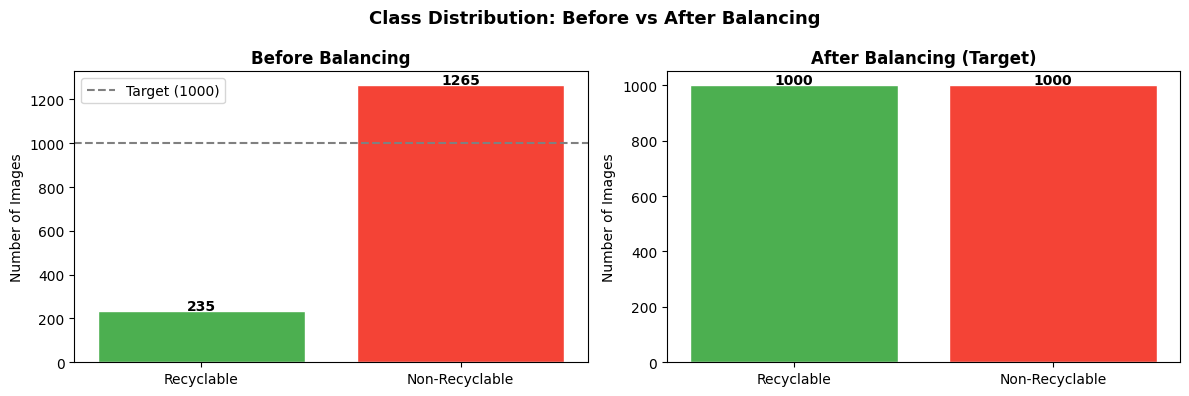

Chart saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

raw_counts = [len(raw_recyclable), len(raw_non_recyclable)]
colors     = ['#4CAF50', '#F44336']

# Before balancing
bars = axes[0].bar(CLASS_NAMES, raw_counts, color=colors, edgecolor='white')
for bar, count in zip(bars, raw_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(count), ha='center', fontweight='bold')
axes[0].set_title('Before Balancing', fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].axhline(y=TARGET_PER_CLASS, color='gray',
                linestyle='--', label=f'Target ({TARGET_PER_CLASS})')
axes[0].legend()

# After balancing (target)
target_counts = [TARGET_PER_CLASS, TARGET_PER_CLASS]
bars2 = axes[1].bar(CLASS_NAMES, target_counts, color=colors, edgecolor='white')
for bar, count in zip(bars2, target_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 str(count), ha='center', fontweight='bold')
axes[1].set_title('After Balancing (Target)', fontweight='bold')
axes[1].set_ylabel('Number of Images')

plt.suptitle('Class Distribution: Before vs After Balancing',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150)
plt.show()
print('Chart saved.')

In [ ]:
def augment_pil(img):
    """
    Apply random augmentations to a PIL Image.
    Returns augmented PIL Image.
    """
    # Horizontal flip
    if random.random() > 0.5:
        img = ImageOps.mirror(img)

    # Random rotation ±15 degrees
    angle = random.uniform(-15, 15)
    img   = img.rotate(angle, resample=Image.BILINEAR, expand=False)

    # Brightness adjustment (0.7 to 1.3)
    factor = random.uniform(0.7, 1.3)
    img    = ImageEnhance.Brightness(img).enhance(factor)

    # Contrast adjustment (0.8 to 1.2)
    factor = random.uniform(0.8, 1.2)
    img    = ImageEnhance.Contrast(img).enhance(factor)

    # Zoom crop (80–100% of image)
    w, h   = img.size
    scale  = random.uniform(0.80, 1.0)
    new_w  = int(w * scale)
    new_h  = int(h * scale)
    left   = random.randint(0, w - new_w)
    top    = random.randint(0, h - new_h)
    img    = img.crop((left, top, left + new_w, top + new_h))
    img    = img.resize((w, h), Image.BILINEAR)

    return img


print('Augmentation function ready.')

Augmentation function ready.


In [ ]:
def load_and_resize(path, size):
    """Load image from path, convert to RGB, resize to size×size."""
    img = Image.open(path).convert('RGB')
    img = img.resize((size, size), Image.BILINEAR)
    return img


def build_balanced_class(paths, target, image_size, class_name):
    """
    Build a balanced list of (numpy_array, label) tuples.
    - Keeps all original images
    - Generates augmented copies until target is reached
    Returns list of numpy arrays (H, W, 3) normalized to [0, 1]
    """
    images = []
    n_original = len(paths)
    n_needed   = target - n_original

    print(f'\n{class_name}:')
    print(f'  Original images : {n_original}')
    print(f'  Augmented needed: {max(0, n_needed)}')

    # If we have more originals than target, randomly sample down
    if n_original > target:
        paths = random.sample(paths, target)
        n_needed = 0
        print(f'  Downsampled to  : {target}')

    # Load all originals
    for path in tqdm(paths, desc=f'  Loading {class_name}'):
        try:
            img = load_and_resize(path, image_size)
            arr = np.array(img, dtype=np.float32) / 255.0
            images.append(arr)
        except Exception as e:
            print(f'  ⚠ Skipped corrupt file: {path}')

    # Generate augmented copies to reach target
    aug_count = 0
    while len(images) < target:
        src_path = random.choice(paths)
        try:
            img = load_and_resize(src_path, image_size)
            img = augment_pil(img)
            arr = np.array(img, dtype=np.float32) / 255.0
            images.append(arr)
            aug_count += 1
        except Exception:
            continue

    print(f'  Augmented added : {aug_count}')
    print(f'  Final count     : {len(images)}')
    return images


# Build both classes
print('Building balanced dataset...')
recyclable_imgs     = build_balanced_class(
    raw_recyclable, TARGET_PER_CLASS, IMAGE_SIZE, 'Recyclable')
non_recyclable_imgs = build_balanced_class(
    raw_non_recyclable, TARGET_PER_CLASS, IMAGE_SIZE, 'Non-Recyclable')

print(f'\n✅ Balanced dataset ready:')
print(f'  Recyclable     : {len(recyclable_imgs)}')
print(f'  Non-Recyclable : {len(non_recyclable_imgs)}')
print(f'  Total          : {len(recyclable_imgs) + len(non_recyclable_imgs)}')

Building balanced dataset...

Recyclable:
  Original images : 235
  Augmented needed: 765


  Loading Recyclable: 100%|██████████| 235/235 [00:43<00:00,  5.36it/s]


  Augmented added : 765
  Final count     : 1000

Non-Recyclable:
  Original images : 1265
  Augmented needed: 0
  Downsampled to  : 1000


  Loading Non-Recyclable: 100%|██████████| 1000/1000 [02:39<00:00,  6.29it/s]

  Augmented added : 0
  Final count     : 1000

✅ Balanced dataset ready:
  Recyclable     : 1000
  Non-Recyclable : 1000
  Total          : 2000


/tmp/ipykernel_35122/1014440958.py:20: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35122/1014440958.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_35122/1014440958.py:21: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_images.png', dpi=150)
/tmp/ipykernel_35122/1014440958.py:21: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_images.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fi

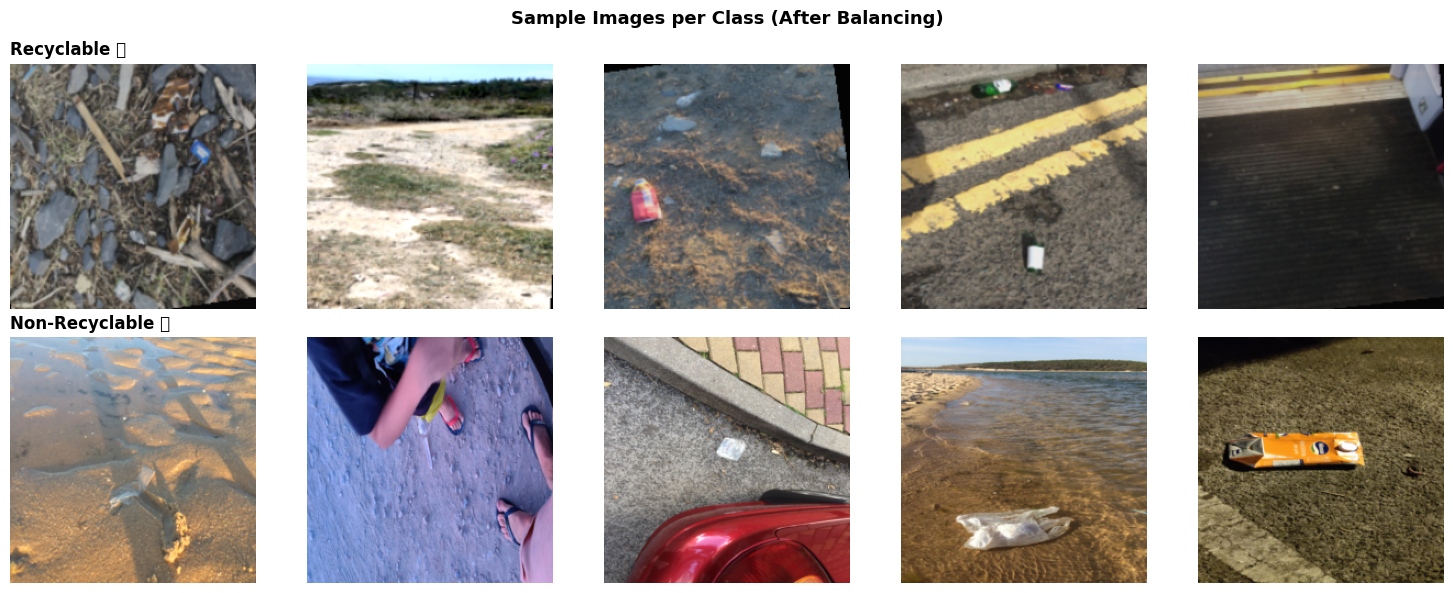

Preview saved.


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for col in range(5):
    # Recyclable row
    idx = random.randint(0, len(recyclable_imgs) - 1)
    axes[0][col].imshow(recyclable_imgs[idx])
    axes[0][col].axis('off')
    if col == 0:
        axes[0][col].set_title('Recyclable ✅', fontweight='bold', loc='left')

    # Non-Recyclable row
    idx = random.randint(0, len(non_recyclable_imgs) - 1)
    axes[1][col].imshow(non_recyclable_imgs[idx])
    axes[1][col].axis('off')
    if col == 0:
        axes[1][col].set_title('Non-Recyclable ❌', fontweight='bold', loc='left')

plt.suptitle('Sample Images per Class (After Balancing)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150)
plt.show()
print('Preview saved.')

In [ ]:
# Combine images and labels
all_images = recyclable_imgs + non_recyclable_imgs
all_labels = ([0] * len(recyclable_imgs) +
              [1] * len(non_recyclable_imgs))

all_images = np.array(all_images, dtype=np.float32)  # shape: (N, 224, 224, 3)
all_labels = np.array(all_labels, dtype=np.int64)

# Shuffle before splitting
indices = np.arange(len(all_images))
np.random.shuffle(indices)
all_images = all_images[indices]
all_labels = all_labels[indices]

# First split: train vs temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    all_images, all_labels,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=all_labels
)

# Second split: val vs test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=y_temp
)

print('Stratified split complete:\n')
print(f'{"Split":8s} {"Total":>8s} {"Recyclable":>12s} {"Non-Rec":>12s}')
print('-' * 45)
for name, X, y in [("Train", X_train, y_train),
                    ("Val",   X_val,   y_val),
                    ("Test",  X_test,  y_test)]:
    rec     = np.sum(y == 0)
    non_rec = np.sum(y == 1)
    print(f'{name:8s} {len(X):>8d} {rec:>12d} {non_rec:>12d}')

print('-' * 45)
total = len(X_train) + len(X_val) + len(X_test)
print(f'{"TOTAL":8s} {total:>8d}')

print(f'\nImage array shape : {X_train.shape}')
print(f'Pixel value range : [{X_train.min():.2f}, {X_train.max():.2f}]')

Stratified split complete:

Split       Total   Recyclable      Non-Rec
---------------------------------------------
Train        1400          700          700
Val           300          150          150
Test          300          150          150
---------------------------------------------
TOTAL        2000

Image array shape : (1400, 224, 224, 3)
Pixel value range : [0.00, 1.00]


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

print('Class weights (for loss function):')
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights)):
    print(f'  [{i}] {name:15s}: {w:.4f}')

print('\nUsage in training:')
print('  criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))')

Class weights (for loss function):
  [0] Recyclable     : 1.0000
  [1] Non-Recyclable : 1.0000

Usage in training:
  criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))


In [ ]:
class WasteDataset(Dataset):
    """
    PyTorch Dataset for waste classification.
    Expects images as numpy arrays (H, W, 3) normalized to [0, 1].
    Applies optional transforms.
    """
    def __init__(self, images, labels, transform=None):
        self.images    = images      # numpy (N, H, W, 3) float32 [0,1]
        self.labels    = labels      # numpy (N,) int64
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img   = self.images[idx]                      # (H, W, 3) float32
        label = int(self.labels[idx])

        # Convert numpy (H,W,C) float32 → PIL → apply transform → tensor
        img_pil = Image.fromarray((img * 255).astype(np.uint8))

        if self.transform:
            img = self.transform(img_pil)
        else:
            img = transforms.ToTensor()(img_pil)

        return img, label


# ── Transforms ─────────────────────────────────────────────────
# MobileNetV2 standard normalization (ImageNet mean/std)
# Even though we train from scratch, this normalization
# keeps pixel values in a stable range for the optimizer.
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ── Datasets ───────────────────────────────────────────────────
train_dataset = WasteDataset(X_train, y_train, transform=train_transform)
val_dataset   = WasteDataset(X_val,   y_val,   transform=val_test_transform)
test_dataset  = WasteDataset(X_test,  y_test,  transform=val_test_transform)

# ── WeightedRandomSampler for balanced batches ─────────────────
sample_weights = [class_weights[label] for label in y_train]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ── DataLoaders ────────────────────────────────────────────────
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2)

print('Datasets and DataLoaders ready.')
print(f'  Train batches : {len(train_loader)}')
print(f'  Val batches   : {len(val_loader)}')
print(f'  Test batches  : {len(test_loader)}')

# Verify one batch
imgs, lbls = next(iter(train_loader))
print(f'\nSample batch:')
print(f'  Image tensor shape : {imgs.shape}')   # (32, 3, 224, 224)
print(f'  Label tensor shape : {lbls.shape}')   # (32,)
print(f'  Label distribution : {Counter(lbls.numpy().tolist())}')

Datasets and DataLoaders ready.
  Train batches : 44
  Val batches   : 10
  Test batches  : 10

Sample batch:
  Image tensor shape : torch.Size([32, 3, 224, 224])
  Label tensor shape : torch.Size([32])
  Label distribution : Counter({1: 16, 0: 16})


In [ ]:
save_data = {
    # Raw numpy arrays
    'X_train': X_train, 'y_train': y_train,
    'X_val':   X_val,   'y_val':   y_val,
    'X_test':  X_test,  'y_test':  y_test,

    # Metadata
    'CLASS_NAMES':       CLASS_NAMES,
    'cat_id_to_class':   cat_id_to_class,
    'class_weights':     class_weights,

    # Config
    'IMAGE_SIZE':        IMAGE_SIZE,
    'TARGET_PER_CLASS':  TARGET_PER_CLASS,
    'SEED':              SEED,
}

with open(OUTPUT_PKL, 'wb') as f:
    pickle.dump(save_data, f)

print(f'Saved: {OUTPUT_PKL}')
print(f'File size: {os.path.getsize(OUTPUT_PKL) / 1024 / 1024:.1f} MB')

Saved: taco_preprocessed_balanced.pkl
File size: 1148.5 MB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

drive_dest = f'/content/drive/MyDrive/waste_classification/{OUTPUT_PKL}'
os.makedirs(os.path.dirname(drive_dest), exist_ok=True)
shutil.copy(OUTPUT_PKL, drive_dest)

print(f'Saved to Google Drive: {drive_dest}')
print('\n✅ Phase 1 complete!')
print('Load this file in your MobileNetV2 training notebook with:')
print(f"  with open('{OUTPUT_PKL}', 'rb') as f: data = pickle.load(f)")

Mounted at /content/drive
Saved to Google Drive: /content/drive/MyDrive/waste_classification/taco_preprocessed_balanced.pkl

✅ Phase 1 complete!
Load this file in your MobileNetV2 training notebook with:
  with open('taco_preprocessed_balanced.pkl', 'rb') as f: data = pickle.load(f)
